# Word embeddings

## Gensim 

### word2vec

In [1]:
from gensim.models import Word2Vec

In [2]:
sentences = [['this', 'is', 'the', 'first', 'sentence', 'for', 'word2vec'],
            ['this', 'is', 'the', 'second', 'sentence'],
            ['yet', 'another', 'sentence'],
            ['one', 'more', 'sentence'],
            ['and', 'the', 'final', 'sentence']]

In [3]:
model = Word2Vec(sentences, min_count=1)
model

In [4]:
list(model.wv.index_to_key)

['sentence',
 'the',
 'is',
 'this',
 'final',
 'and',
 'more',
 'one',
 'another',
 'yet',
 'second',
 'word2vec',
 'for',
 'first']

In [5]:
model.wv['sentence']

array([-5.3622725e-04,  2.3643136e-04,  5.1033497e-03,  9.0092728e-03,
       -9.3029495e-03, -7.1168090e-03,  6.4588725e-03,  8.9729885e-03,
       -5.0154282e-03, -3.7633716e-03,  7.3805046e-03, -1.5334714e-03,
       -4.5366134e-03,  6.5540518e-03, -4.8601604e-03, -1.8160177e-03,
        2.8765798e-03,  9.9187379e-04, -8.2852151e-03, -9.4488179e-03,
        7.3117660e-03,  5.0702621e-03,  6.7576934e-03,  7.6286553e-04,
        6.3508903e-03, -3.4053659e-03, -9.4640139e-04,  5.7685734e-03,
       -7.5216377e-03, -3.9361035e-03, -7.5115822e-03, -9.3004224e-04,
        9.5381187e-03, -7.3191668e-03, -2.3337686e-03, -1.9377411e-03,
        8.0774371e-03, -5.9308959e-03,  4.5162440e-05, -4.7537340e-03,
       -9.6035507e-03,  5.0072931e-03, -8.7595852e-03, -4.3918253e-03,
       -3.5099984e-05, -2.9618145e-04, -7.6612402e-03,  9.6147433e-03,
        4.9820580e-03,  9.2331432e-03, -8.1579173e-03,  4.4957981e-03,
       -4.1370760e-03,  8.2453608e-04,  8.4986202e-03, -4.4621765e-03,
      

### Plot word2vec

In [6]:
from sklearn.decomposition import PCA
from matplotlib import pyplot

In [7]:
X = model.wv[model.wv.index_to_key]

In [8]:
pca = PCA(n_components=2)
result = pca.fit_transform(X)

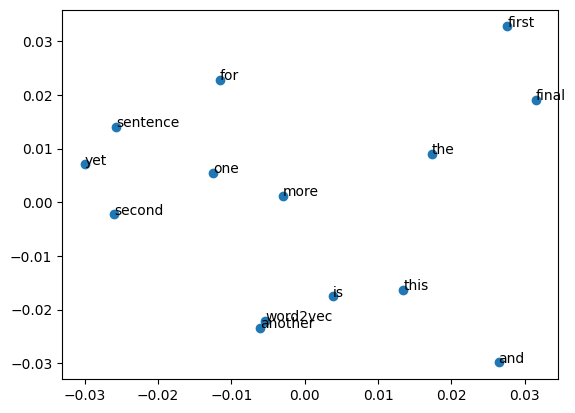

In [10]:
pyplot.scatter(result[:, 0], result[:, 1])
words = list(model.wv.index_to_key)
for i, word in enumerate(words):
    pyplot.annotate(word, xy=(result[i, 0], result[i, 1]))

In [ ]:
#model.save('model.bin')
#new_model = Word2Vec.load('model.bin')

### Pretrained  Google’s word2vec

In [ ]:
from gensim.models import KeyedVectors
filename = 'GoogleNews-vectors-negative300.bin'
model = KeyedVectors.load_word2vec_format(filename, binary=True)

### Stanford’s GloVe Embedding

In [ ]:
from gensim.scripts.glove2word2vec import glove2word2vec
glove_input_file = 'glove.txt'
word2vec_output_file = 'word2vec.txt'
glove2word2vec(glove_input_file, word2vec_output_file)

## Keras

### Embedding

In [9]:
from keras.layers import Embedding, Flatten, Dense
from keras import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences

import numpy as np

In [10]:
docs = ['Well done!',
		'Good work',
		'Great effort',
		'nice work',
		'Excellent!',
		'Weak',
		'Poor effort!',
		'not good',
		'poor work',
		'Could have done better.']

labels = np.array([1,1,1,1,1,0,0,0,0,0])

In [11]:
vocab_size = 50
encoded_docs = [one_hot(d, vocab_size) for d in docs]
print(encoded_docs)

[[19, 18], [17, 40], [15, 36], [35, 40], [27], [4], [3, 36], [27, 17], [3, 40], [31, 29, 18, 35]]


In [12]:
# pad documents to a max length of 4 words
max_length = 4
padded_docs = pad_sequences(encoded_docs, maxlen=max_length, padding='post')
print(padded_docs)

[[19 18  0  0]
 [17 40  0  0]
 [15 36  0  0]
 [35 40  0  0]
 [27  0  0  0]
 [ 4  0  0  0]
 [ 3 36  0  0]
 [27 17  0  0]
 [ 3 40  0  0]
 [31 29 18 35]]


In [13]:
model = Sequential()
model.add(Embedding(vocab_size, 8, input_length=max_length))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# summarize the model
print(model.summary())

c:\python\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
model.fit(padded_docs, labels, epochs=50, verbose=0)
loss, accuracy = model.evaluate(padded_docs, labels, verbose=0)
print('Accuracy: %f' % (accuracy*100))

Accuracy: 100.000000


### Glove

In [15]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
docs = ['Well done!',
		'Good work',
		'Great effort',
		'nice work',
		'Excellent!',
		'Weak',
		'Poor effort!',
		'not good',
		'poor work',
		'Could have done better.']
# define class labels
labels = np.array([1,1,1,1,1,0,0,0,0,0])

t = Tokenizer()
t.fit_on_texts(docs)
vocab_size = len(t.word_index) + 1

encoded_docs = t.texts_to_sequences(docs)
print(encoded_docs)

max_length = 4
padded_docs = pad_sequences(encoded_docs, maxlen=max_length, padding='post')
print(padded_docs)

embeddings_index = dict()
f = open('../glove_data/glove.6B/glove.6B.100d.txt')
for line in f:
	values = line.split()
	word = values[0]
	coefs = np.asarray(values[1:], dtype='float32')
	embeddings_index[word] = coefs
f.close()
print('Loaded %s word vectors.' % len(embeddings_index))

embedding_matrix = np.zeros((vocab_size, 100))
for word, i in t.word_index.items():
	embedding_vector = embeddings_index.get(word)
	if embedding_vector is not None:
		embedding_matrix[i] = embedding_vector

model = Sequential()
e = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=4, trainable=False)
model.add(e)
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(model.summary())

model.fit(padded_docs, labels, epochs=50, verbose=0)

loss, accuracy = model.evaluate(padded_docs, labels, verbose=0)
print('Accuracy: %f' % (accuracy*100))

## Torch

In [16]:
import torch
import torch.nn as nn

# Tiny vocabulary: word -> index
word_to_idx = {
    'hello': 0,
    'world': 1,
    'how': 2,
    'are': 3,
    'you': 4
}
vocab_size = len(word_to_idx)
embedding_dim = 4

# Embedding layer
embedding = nn.Embedding(vocab_size, embedding_dim)

# Sentence: "hello world" -> indices [0, 1]
sentence = ['hello', 'world']
indices = torch.tensor([word_to_idx[w] for w in sentence])  # [0, 1]

# Get embeddings
vectors = embedding(indices)
print("Word indices:", indices)
print("Embeddings:\n", vectors)
print("Shape:", vectors.shape)   # (2, 4)

Word indices: tensor([0, 1])
Embeddings:
 tensor([[-0.0933,  0.3431, -0.8060, -0.1445],
        [-1.2003,  1.3229, -0.4592,  1.5966]], grad_fn=<EmbeddingBackward0>)
Shape: torch.Size([2, 4])


Train embedding

In [17]:
import torch.optim as optim

In [18]:
sentences = [
    "i love this movie",      # positive (1)
    "this film is great",     # positive (1)
    "i hate this film",       # negative (0)
    "terrible movie"          # negative (0)
]
labels = torch.tensor([1, 1, 0, 0])

In [19]:
word_to_idx = {'<PAD>': 0}   # token for padding
for sent in sentences:
    for word in sent.lower().split():
        if word not in word_to_idx:
            word_to_idx[word] = len(word_to_idx)

vocab_size = len(word_to_idx)
print("Vocabulary:", word_to_idx)

Vocabulary: {'<PAD>': 0, 'i': 1, 'love': 2, 'this': 3, 'movie': 4, 'film': 5, 'is': 6, 'great': 7, 'hate': 8, 'terrible': 9}


In [20]:
max_len = max(len(sent.split()) for sent in sentences)
encoded_sentences = []
for sent in sentences:
    indices = [word_to_idx[word.lower()] for word in sent.split()]
    # padding
    indices += [0] * (max_len - len(indices))
    encoded_sentences.append(indices)
    
input_tensor = torch.tensor(encoded_sentences)  # shape (4, max_len)
print("Sentences idx:\n", input_tensor)

Sentences idx:
 tensor([[1, 2, 3, 4],
        [3, 5, 6, 7],
        [1, 8, 3, 5],
        [9, 4, 0, 0]])


In [21]:
class SimpleEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)            # (batch, seq_len, embed_dim)
        pooled = emb.mean(dim=1)           # normalization -> (batch, embed_dim)
        return self.fc(pooled)

In [22]:
embedding_dim = 8
num_classes = 2
pad_idx = word_to_idx['<PAD>']

model = SimpleEmbeddingClassifier(vocab_size, embedding_dim, num_classes, pad_idx)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

for epoch in range(30):
    optimizer.zero_grad()
    outputs = model(input_tensor)          # (4, 2)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, loss = {loss.item():.4f}")

test_sentences = ["i love great film", "hate terrible movie"]
test_encoded = []
for sent in test_sentences:
    indices = [word_to_idx.get(word.lower(), 0) for word in sent.split()]  # неизвестные слова -> 0 (PAD)
    indices += [0] * (max_len - len(indices))
    test_encoded.append(indices)

test_tensor = torch.tensor(test_encoded)
with torch.no_grad():
    preds = model(test_tensor)
    predicted_classes = torch.argmax(preds, dim=1)
    print("\nTest results:")
    for sent, pred in zip(test_sentences, predicted_classes):
        print(f"'{sent}' -> {'positive' if pred == 1 else 'negative'}")

Epoch 0, loss = 0.7539
Epoch 10, loss = 0.1563
Epoch 20, loss = 0.0091

Test results:
'i love great film' -> positive
'hate terrible movie' -> negative
